# Üzüm Yaprağı Hastalık Tespiti

Bu proje, artırılmış (augmented) üzüm yaprağı görüntülerinden yola çıkarak dört farklı sınıfı (Kara Çürük (Black Rot), Kara Kızamık (Esca), Yaprak Yanıklığı (Leaf Blight) ve Sağlıklı) sınıflandırmak için derin öğrenme modelleri geliştirmeyi amaçlamaktadır.

Proje, iki aşamada ilerleyecektir:

- Sıfırdan CNN Geliştirme: Minimum 5 Evrişimli (Convolutional) ve 3 Havuzlama (Pooling) katmanına sahip, transfer öğrenmesiz, özelleştirilmiş ve düzenleme (regularization) içeren bir Derin Evrişimli Sinir Ağı (Deep CNN) kurulması ve eğitilmesi.

- Transfer Öğrenimi Uygulaması: VGG16, ResNet gibi önceden eğitilmiş bir model (Transfer Learning) kullanılarak aynı sınıflandırma görevinin tekrarlanması.

In [42]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization, Input, GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from sklearn.metrics import classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

In [4]:
# !pip install protobuf==3.20.3 --force-reinstall

In [4]:
# statik veriler tanimliyoruz
DATA_DIR = '/kaggle/input/augmented-grape-disease-detection-dataset/Final Training Data'
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
RANDOM_SEED = 42

In [5]:
# %20'lik bir doğrulama bölümü kullanıyoruz
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

In [6]:
train_gen = datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=RANDOM_SEED
)

Found 9600 images belonging to 4 classes.


In [7]:
val_gen = datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=RANDOM_SEED
)

Found 2400 images belonging to 4 classes.


### EDA - Exploratory Data Analysis

In [14]:
# Sinif isimlerini alalim
class_names = list(train_gen.class_indices.keys())

In [15]:
class_names

['Black Rot', 'ESCA', 'Healthy', 'Leaf Blight']

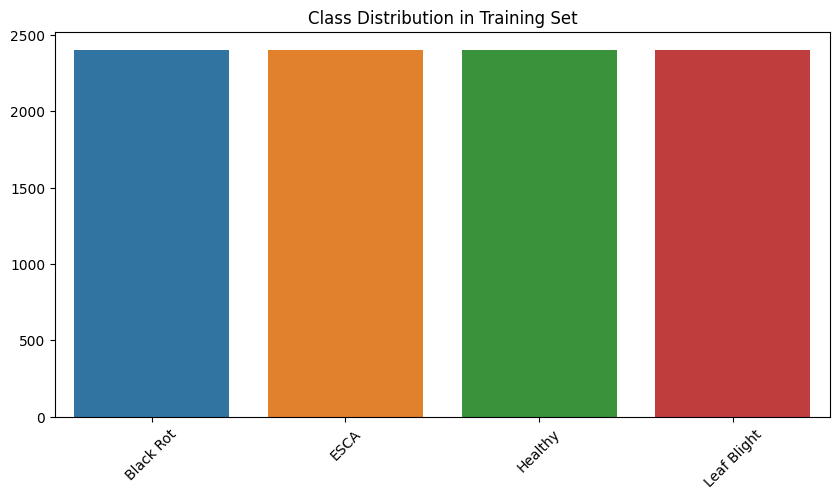

In [16]:
# Sınıf dağılımını görselleştelim
class_counts = pd.Series(train_gen.classes).value_counts().sort_index()
plt.figure(figsize=(10, 5))
sns.barplot(x=class_names, y=class_counts.values)
plt.title("Class Distribution in Training Set")
plt.xticks(rotation=45)
plt.show()

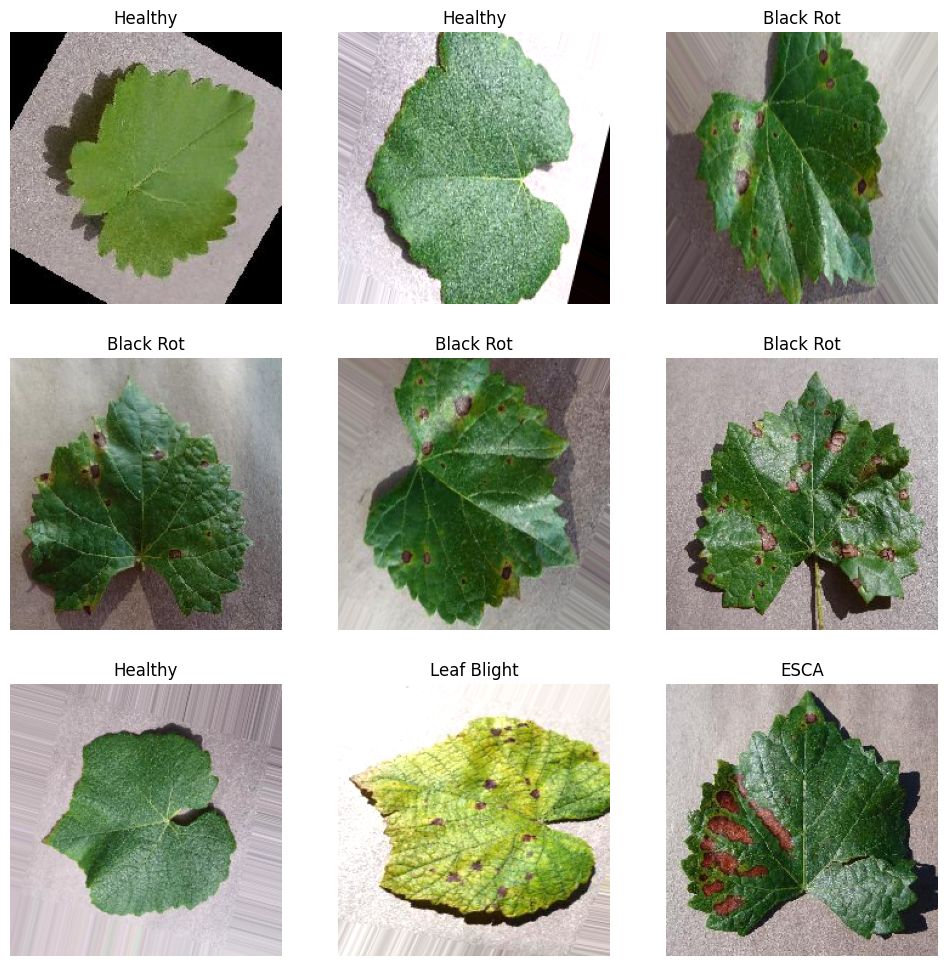

In [17]:
# Örnek resimleri gösterelim
x_batch, y_batch = next(train_gen)
plt.figure(figsize=(12, 12))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_batch[i])
    label_index = np.argmax(y_batch[i])
    plt.title(class_names[label_index])
    plt.axis("off")
plt.show()

### Deep CNN

In [43]:
# >5 Conv Layers, >3 Pool Layers, Regularization (Dropout/BatchNorm)
def build_custom_cnn(input_shape, num_classes):
    model = Sequential()
    model.add(Input(shape=input_shape))
    # Block 1 (Conv + Pool) - 
    model.add(Conv2D(32, (3, 3), activation='relu', padding='same', kernel_regularizer=l2(0.0001)))
    model.add(BatchNormalization()) # Regularization
    model.add(MaxPooling2D((2, 2)))
    # Block 2 (Conv + Pool)
    model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2, 2)))
    # Block 3 (Conv + Pool)
    model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2, 2)))
    # Block 4 (Conv + Conv) - Deepening the network
    model.add(Conv2D(256, (3, 3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(Dropout(0.3)) # Regularization
    # Block 5 (Conv + Pool)
    model.add(Conv2D(256, (3, 3), activation='relu', padding='same'))
    model.add(MaxPooling2D((2, 2)))
    # Block 6 (Conv - Extra to meet >5 requirement)
    model.add(Conv2D(512, (3, 3), activation='relu', padding='same', kernel_regularizer=l2(0.0001)))
    model.add(BatchNormalization())
    # Flatten and Dense
    model.add(Flatten())
    model.add(Dense(512, activation='relu'))
    model.add(Dropout(0.5)) # Regularization
    model.add(Dense(num_classes, activation='softmax'))
    return model

In [44]:
# Belirlenen giriş boyutu (224x224x3) ve sınıf sayısı (4) ile özel CNN mimarisini (build_custom_cnn) oluşturur.
custom_model = build_custom_cnn(input_shape=IMG_SIZE + (3,), num_classes=len(class_names))

In [45]:
# Modelin Derlenmesi (Eğitime Hazırlık)
custom_model.compile(
    # Hata Azaltma Yöntemi: Genellikle en iyi çalışan 'Adam' optimizasyon algoritması seçildi.
    optimizer='adam', 
    # Hata Fonksiyonu: Çok sınıflı sınıflandırma için uygun olan 'Categorical Crossentropy' seçildi.
    loss='categorical_crossentropy', 
    # Başarı Kriterleri: Doğruluk (Accuracy) ile birlikte detaylı analiz için Kesinlik (Precision) ve Duyarlılık (Recall) eklendi.
    metrics=['accuracy', 'Precision', 'Recall']
)

In [46]:
custom_model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_24 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 28, 28, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 14, 14, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 14, 14, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 512)            │    51,380,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,545,412 (204.26 MB)

 Trainable params: 53,543,428 (204.25 MB)

 Non-trainable params: 1,984 (7.75 KB)

In [47]:
# early_stopping validation_loss'u izle ile 5 epoch boyunca iyileşme olmazsa durdur 
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True,verbose=1)

In [48]:
# Train Custom Model
history_custom = custom_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=50, # Epoch sayısını yüksek tutabiliriz, çünkü EarlyStopping durduracak
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 54s 152ms/step - Precision: 0.7354 - Recall: 0.6966 - accuracy: 0.7182 - loss: 3.3816 - val_Precision: 0.4442 - val_Recall: 0.4442 - val_accuracy: 0.4442 - val_loss: 12.3294
Epoch 2/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 35s 116ms/step - Precision: 0.8868 - Recall: 0.8356 - accuracy: 0.8681 - loss: 0.4354 - val_Precision: 0.8087 - val_Recall: 0.8012 - val_accuracy: 0.8042 - val_loss: 0.8100
Epoch 3/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 34s 113ms/step - Precision: 0.9239 - Recall: 0.8813 - accuracy: 0.9057 - loss: 0.3587 - val_Precision: 0.9118 - val_Recall: 0.8958 - val_accuracy: 0.9013 - val_loss: 0.3084
Epoch 4/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 34s 113ms/step - Precision: 0.9340 - Recall: 0.9149 - accuracy: 0.9253 - loss: 0.3063 - val_Precision: 0.8201 - val_Recall: 0.7788 - val_accuracy: 0.8037 - val_loss: 1.8336
Epoch 5/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 34s 113ms/step - Precision: 0.9488 - Recall: 0.9222 - accuracy: 0.9358 - loss: 0.2661 - val_Precision: 0.78

In [50]:
# Plotting Metrics
def plot_history(history, model_name):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    
    epochs = range(len(acc))
    
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'b', label='Training acc')
    plt.plot(epochs, val_acc, 'r', label='Validation acc')
    plt.title(f'{model_name} Accuracy')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'b', label='Training loss')
    plt.plot(epochs, val_loss, 'r', label='Validation loss')
    plt.title(f'{model_name} Loss')
    plt.legend()
    plt.show()

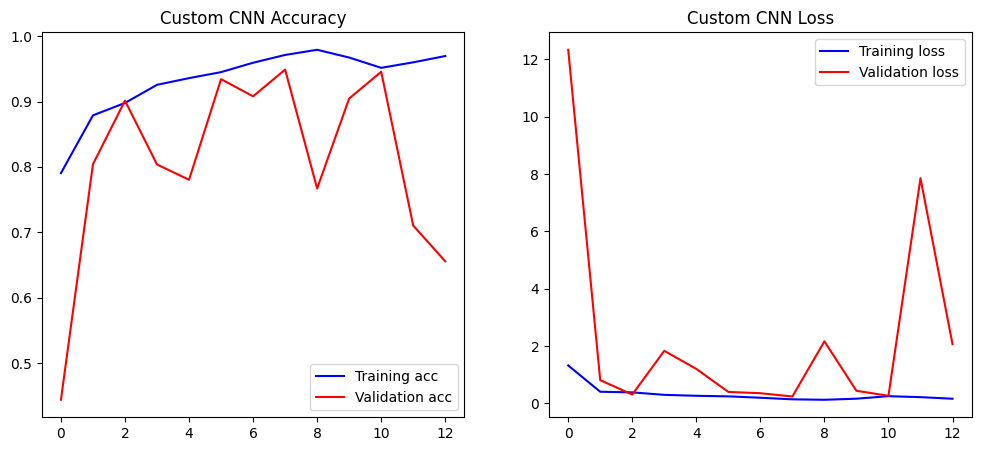

In [51]:
plot_history(history_custom, "Custom CNN")

In [52]:
# Custom CNN sonuclari
val_loss, val_acc, val_prec, val_rec = custom_model.evaluate(val_gen)
print(f"Loss: {val_loss:.4f}, Accuracy: {val_acc:.4f}, Precision: {val_prec:.4f}, Recall: {val_rec:.4f}")

75/75 ━━━━━━━━━━━━━━━━━━━━ 6s 79ms/step - Precision: 0.9535 - Recall: 0.9392 - accuracy: 0.9460 - loss: 0.2503
Loss: 0.2410, Accuracy: 0.9488, Precision: 0.9560, Recall: 0.9408


Kayıp (Loss)	0.2410	Düşük kayıp, modelin iyi öğrendiğini gösterir.
Doğruluk (Accuracy)	%94.88	4 farklı üzüm yaprağı sınıfını %94.88 doğrulukla tespit edebiliyor.
Kesinlik (Precision)	0.9560	Model, yaptığı pozitif tahminlerin büyük çoğunluğunda (%95.6) haklıdır (Yanlış pozitif oranı düşüktür).
Duyarlılık (Recall)	0.9408	Model, gerçek hastalıklı/sağlıklı vakaların çoğunu (%94.08) yakalayabilmiştir (Yanlış negatif oranı düşüktür).

In [53]:
# Modelin kaydedilmesi
custom_model.save('grape_custom_model.keras')

### Transfer Learning (VGG16) Modelini Eğitme

Simdi baskalarinin aklini kullanarak transfer learning yapalim.

In [54]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [55]:
def build_transfer_model(input_shape, num_classes):
    # VGG16 modelini ImageNet ağırlıklarıyla ve üst katmanlar olmadan yükle
    base_model = VGG16(weights='imagenet', include_top=False, input_shape=input_shape)
    # Base model katmanlarını dondur (Eğitimi engelle)
    for layer in base_model.layers:
        layer.trainable = False  
    # Yeni sınıflandırma başlığını ekle
    x = base_model.output
    x = Flatten()(x)
    x = Dense(512, activation='relu')(x)
    x = Dropout(0.5)(x)
    predictions = Dense(num_classes, activation='softmax')(x)
    model = Model(inputs=base_model.input, outputs=predictions)
    return model

In [60]:
# Early Stopping'i tekrar tanımlayoruz (patience=3 ile)
early_stopping_tl = EarlyStopping(
    monitor='val_loss', 
    patience=3, # Daha hızlı yakınsama bekliyoruz
    restore_best_weights=True,
    verbose=1
)

In [61]:
# Belirlenen giriş boyutu (224x224x3) ve sınıf sayısı (4) ilebuild_transfer_model oluşturur.
tl_model = build_transfer_model(input_shape=IMG_SIZE + (3,), num_classes=len(class_names))

In [62]:
# Modelin Derlenmesi (Eğitime Hazırlık)
tl_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy', 'Precision', 'Recall'])

In [63]:
tl_model.summary()

Model: "functional_101"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 512)            │    12,845,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,562,308 (105.14 MB)

 Trainable params: 12,847,620 (49.01 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [64]:
# VGG16 Train Transfer Learning Model
history_tl = tl_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10, 
    callbacks=[early_stopping_tl], # Early Stopping kullan
    verbose=1
)

Epoch 1/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 98s 272ms/step - Precision: 0.7577 - Recall: 0.7224 - accuracy: 0.7418 - loss: 1.4986 - val_Precision: 0.9652 - val_Recall: 0.9592 - val_accuracy: 0.9625 - val_loss: 0.1209
Epoch 2/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 79s 265ms/step - Precision: 0.9425 - Recall: 0.9335 - accuracy: 0.9374 - loss: 0.1589 - val_Precision: 0.9537 - val_Recall: 0.9529 - val_accuracy: 0.9529 - val_loss: 0.1209
Epoch 3/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 79s 262ms/step - Precision: 0.9573 - Recall: 0.9527 - accuracy: 0.9549 - loss: 0.1164 - val_Precision: 0.9729 - val_Recall: 0.9725 - val_accuracy: 0.9725 - val_loss: 0.0834
Epoch 4/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 79s 264ms/step - Precision: 0.9640 - Recall: 0.9589 - accuracy: 0.9608 - loss: 0.1020 - val_Precision: 0.9541 - val_Recall: 0.9538 - val_accuracy: 0.9538 - val_loss: 0.1095
Epoch 5/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 79s 265ms/step - Precision: 0.9566 - Recall: 0.9528 - accuracy: 0.9552 - loss: 0.1111 - val_Precision: 0.968

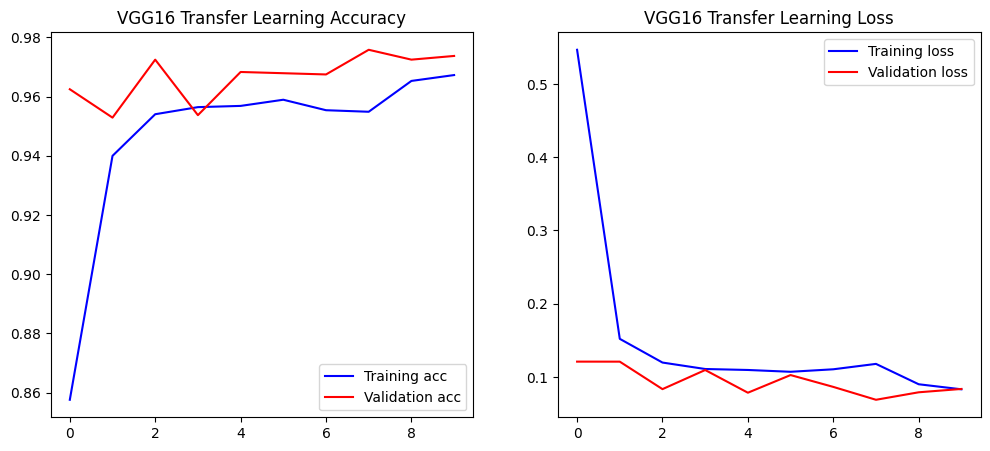

In [65]:
# Plotting Metrics
plot_history(history_tl, "VGG16 Transfer Learning")

In [67]:
# VGG16 Modelinin Doğrulama Kümesinde Değerlendirilmesi (En İyi Ağırlıklar)...
val_loss, val_acc, val_prec, val_rec = tl_model.evaluate(val_gen)
print(f"Validation Loss: {val_loss:.4f}, Accuracy: {val_acc:.4f}, Precision: {val_prec:.4f}, Recall: {val_rec:.4f}")

75/75 ━━━━━━━━━━━━━━━━━━━━ 16s 214ms/step - Precision: 0.9755 - Recall: 0.9755 - accuracy: 0.9755 - loss: 0.0741
Validation Loss: 0.0688, Accuracy: 0.9758, Precision: 0.9758, Recall: 0.9754


In [71]:
# Modelin kaydedilmesi
tl_model.save('grape_tl_model.keras')

### Sonuc

En Yüksek Doğruluk: VGG16, hiç görmediği doğrulama verilerinde Custom CNN'den yaklaşık %2.7 daha yüksek doğruluk elde etmiştir (%97.58 vs. %94.88).

En Düşük Hata: VGG16'nın hata oranı (Loss: 0.0688), Custom CNN'e göre yaklaşık 3.5 kat daha düşüktür (0.2410). Bu, VGG16'nın tahminlerinin çok daha güvenilir ve kesin olduğu anlamına gelir.

Dengeli Metrikler: VGG16'da Precision ve Recall metrikleri de en yüksek değerlere sahiptir, bu da modelin hem hastalıkları doğru etiketleme (Kesinlik) hem de hastalık vakalarını kaçırmama (Duyarlılık) konusunda dengeli ve başarılı olduğunu gösterir.

Doğrulama veri seti ve etiketleri toplanıyor...
Veri toplama tamamlandı. Tahmin yapılıyor...
75/75 ━━━━━━━━━━━━━━━━━━━━ 17s 214ms/step


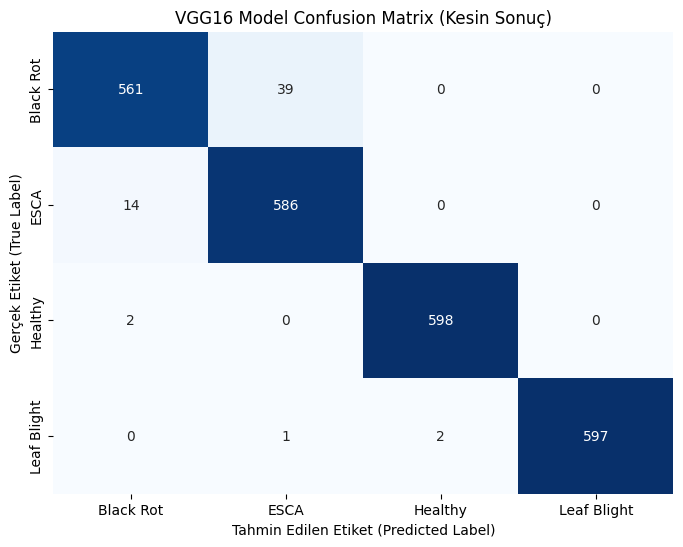


VGG16 Model Sınıflandırma Raporu (Kesin Sonuç)
              precision    recall  f1-score   support

   Black Rot       0.97      0.94      0.95       600
        ESCA       0.94      0.98      0.96       600
     Healthy       1.00      1.00      1.00       600
 Leaf Blight       1.00      0.99      1.00       600

    accuracy                           0.98      2400
   macro avg       0.98      0.98      0.98      2400
weighted avg       0.98      0.98      0.98      2400



In [70]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Veri ve Etiketleri Sırayla Toplama
print("Doğrulama veri seti ve etiketleri toplanıyor...")
val_gen.reset()

# Tüm örnek sayısını hesapla
num_samples = len(val_gen.filenames)
# Generator'ın kaç adımda biteceğini hesapla (ceil, küsüratı üste yuvarlar)
num_steps = np.ceil(num_samples / val_gen.batch_size) 

# Veri ve etiketleri tutacak boş listeler
X_val = []
Y_val = []

# Generator'dan tüm veriyi çek
for i in range(int(num_steps)):
    X, Y = val_gen[i]
    X_val.append(X)
    Y_val.append(Y)

# NumPy dizilerine dönüştür
X_val = np.concatenate(X_val)
Y_val = np.concatenate(Y_val)
y_true_one_hot = Y_val
y_true = np.argmax(Y_val, axis=1) # Gerçek etiketleri (tamsayı) al

print("Veri toplama tamamlandı. Tahmin yapılıyor...")

# 2. Toplanan Veri Üzerinden Tahminleri Yap
Y_pred = tl_model.predict(X_val)
y_pred = np.argmax(Y_pred, axis=1) # Tahmin edilen etiketleri (tamsayı) al

# Sınıf İsimleri (class_names'in mevcut olduğunu varsayıyoruz)
try:
    class_labels = class_names
except NameError:
    class_labels = list(val_gen.class_indices.keys())

# 3. Karar Matrisi (Confusion Matrix) oluştur ve görselleştir
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('VGG16 Model Confusion Matrix (Kesin Sonuç)')
plt.ylabel('Gerçek Etiket (True Label)')
plt.xlabel('Tahmin Edilen Etiket (Predicted Label)')
plt.show()

# 4. Sınıflandırma Raporu (Classification Report)
print("\n" + "="*50)
print("VGG16 Model Sınıflandırma Raporu (Kesin Sonuç)")
print("="*50)
print(classification_report(y_true, y_pred, target_names=class_labels))